# SER Training - Optimized
Dùng preprocessed features (.npy), augmentation online, mixed precision training

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet34, ResNet34_Weights
from torch.amp.autocast_mode import autocast
from torch.amp.grad_scaler import GradScaler
import librosa
from prettytable import PrettyTable

from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

Device: cuda


## Config

In [2]:
# ===== CONFIG =====
EMOTION_MAP = {
    "ANG": 0,
    "DIS": 1,
    "FEA": 2,
    "HAP": 3,
    "NEU": 4,
    "SAD": 5
}
NUM_CLASSES = len(EMOTION_MAP)

LEARNING_RATE = 5e-5   # Lower: was 1e-4
FC_LEARNING_RATE = 5e-4  # Lower: was 1e-3
WEIGHT_DECAY = 5e-4
BATCH_SIZE = 32
EPOCHS = 100
PATIENCE = 5  # Early stopping

FEATURE_DIR = "features"
CHECKPOINT_DIR = "checkpoints"
NUM_WORKERS = 0
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## Data

In [3]:
TARGET_SHAPE = (3, 128, 174)  # 174 frames ≈ 2s @ 16kHz, 100 hop_length
 
 
def extract_features(y, sr):
    """Extract mel + delta + delta²"""
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=512,
        hop_length=100,
        n_mels=128
    )
    mel = librosa.power_to_db(mel)
    
    delta = librosa.feature.delta(mel)
    delta2 = librosa.feature.delta(mel, order=2)
    
    feature = np.stack([mel, delta, delta2], axis=0)
    return feature
 
 
def normalize_feature(feature):
    """Normalize từng channel riêng"""
    normalized = np.zeros_like(feature, dtype=np.float32)
    for c in range(feature.shape[0]):
        mean = feature[c].mean()
        std = feature[c].std()
        normalized[c] = (feature[c] - mean) / (std + 1e-6)
    return normalized
 
 
def pad_or_crop(feature, target_shape):
    """Pad hoặc crop feature về target_shape"""
    # feature shape: (3, 128, T)
    assert feature.shape[0] == target_shape[0], "Channel mismatch"
    assert feature.shape[1] == target_shape[1], "Mel bands mismatch"
    
    target_t = target_shape[2]
    current_t = feature.shape[2]
    
    if current_t == target_t:
        return feature
    elif current_t < target_t:
        # Pad
        pad_amount = target_t - current_t
        pad_left = pad_amount // 2
        pad_right = pad_amount - pad_left
        padded = np.pad(
            feature,
            ((0, 0), (0, 0), (pad_left, pad_right)),
            mode='constant',
            constant_values=-80  # dB value cho silence
        )
        return padded
    else:
        # Crop từ giữa
        start = (current_t - target_t) // 2
        return feature[:, :, start:start + target_t]
 
 
def preprocess_dataset(dataset_dir, output_dir, stage="train"):
    """
    Preprocess toàn bộ dataset
    
    Args:
        dataset_dir: Thư mục chứa .wav files
        output_dir: Thư mục lưu .npy
        stage: "train", "val", "test" (chỉ để logging)
    """
    os.makedirs(output_dir, exist_ok=True)
    
    file_paths = []
    labels = []
    
    # Collect files
    for file in os.listdir(dataset_dir):
        if not file.endswith(".wav"):
            continue
        
        emotion = file.split("_")[2]
        if emotion not in EMOTION_MAP:
            continue
        
        file_paths.append(os.path.join(dataset_dir, file))
        labels.append(EMOTION_MAP[emotion])
    
    print(f"\n[{stage}] Found {len(file_paths)} files")
    
    # Process
    for idx, (audio_path, label) in enumerate(tqdm(zip(file_paths, labels), 
                                                     total=len(file_paths),
                                                     desc=f"Preprocessing {stage}")):
        try:
            # Load audio
            y, sr = librosa.load(audio_path, sr=16000)
            
            # Extract features
            feature = extract_features(y, sr)
            
            # Normalize
            feature = normalize_feature(feature)
            
            # Pad/crop
            feature = pad_or_crop(feature, TARGET_SHAPE)
            
            # Save
            np.save(f"{output_dir}/{idx:05d}.npy", feature.astype(np.float32))
            
            # Lưu label trong file riêng
            with open(f"{output_dir}/{idx:05d}.txt", "w") as f:
                f.write(str(label))
        
        except Exception as e:
            print(f"Error processing {audio_path}: {e}")
            continue
    
    # Lưu mapping file
    with open(f"{output_dir}/metadata.txt", "w") as f:
        for idx, (path, label) in enumerate(zip(file_paths, labels)):
            f.write(f"{idx:05d}\t{path}\t{label}\n")
    
    print(f"[{stage}] Saved to {output_dir}/")
    return len(file_paths)

if os.path.exists(FEATURE_DIR) and len(os.listdir(FEATURE_DIR)) > 0:
    print(f"Features already exist in {FEATURE_DIR}, skipping preprocessing.")
else:
    count = preprocess_dataset("dataset/cremad/AudioWAV", "features", stage="full")

Features already exist in features, skipping preprocessing.


## Dataset - Load từ .npy

In [4]:
def augment_feature_online(feature):
    """Augmentation online trên mel-spectrogram (3, 128, 174)"""
    feature = feature.copy()
    
    # Time masking (SpecAugment)
    if random.random() < 0.3:
        t_mask = random.randint(5, 30)
        t_start = random.randint(0, feature.shape[2] - t_mask)
        feature[:, :, t_start:t_start + t_mask] = -80  # silence
    
    # Frequency masking
    if random.random() < 0.3:
        f_mask = random.randint(5, 20)
        f_start = random.randint(0, 128 - f_mask)
        feature[:, f_start:f_start + f_mask, :] = -80
    
    # Gain (scale amplitude)
    if random.random() < 0.3:
        gain = random.uniform(0.8, 1.2)
        feature = feature * gain
    
    return feature


class PreprocessedDataset(Dataset):
    """Load từ preprocessed .npy features"""
    
    def __init__(self, feature_dir, indices, augment=False):
        self.feature_dir = feature_dir
        self.indices = indices
        self.augment = augment
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        file_idx = self.indices[idx]
        
        # Load feature
        feature_path = os.path.join(self.feature_dir, f"{file_idx:05d}.npy")
        feature = np.load(feature_path)  # (3, 128, 174)
        
        # Load label
        label_path = os.path.join(self.feature_dir, f"{file_idx:05d}.txt")
        with open(label_path, 'r') as f:
            label = int(f.read().strip())
        
        # Augmentation
        if self.augment:
            feature = augment_feature_online(feature)
        
        # Reshape: (3, 128, 174) -> (3, 224, 224) với padding
        # Resize dùng cv2
        feature_resized = np.zeros((3, 224, 224), dtype=np.float32)
        for c in range(3):
            # Normalize to [0, 1] trước resize
            ch = feature[c]
            ch_norm = (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)
            # Resize
            ch_resized = cv2.resize(ch_norm, (224, 224), interpolation=cv2.INTER_LINEAR)
            feature_resized[c] = ch_resized
        
        feature_tensor = torch.tensor(feature_resized, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        return feature_tensor, label_tensor


import cv2
print("Dataset class defined")

Dataset class defined


In [5]:
# Load metadata
metadata_path = os.path.join(FEATURE_DIR, "metadata.txt")
all_indices = []
all_labels = []

with open(metadata_path, 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        idx = int(parts[0])
        label = int(parts[2])
        all_indices.append(idx)
        all_labels.append(label)

print(f"Total samples: {len(all_indices)}")
print(f"Label distribution: {np.bincount(all_labels)}")

Total samples: 7442
Label distribution: [1271 1271 1271 1271 1087 1271]


In [6]:
# Split: 70% train, 15% val, 15% test
train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    all_indices, all_labels,
    test_size=0.3,
    stratify=all_labels,
    random_state=42
)

val_idx, test_idx, val_labels, test_labels = train_test_split(
    temp_idx, temp_labels,
    test_size=2/3,
    stratify=temp_labels,
    random_state=42
)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 5209, Val: 744, Test: 1489


In [7]:
# Create datasets & loaders
train_dataset = PreprocessedDataset(FEATURE_DIR, train_idx, augment=True)
val_dataset = PreprocessedDataset(FEATURE_DIR, val_idx, augment=False)
test_dataset = PreprocessedDataset(FEATURE_DIR, test_idx, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"DataLoaders created. First batch shape: {next(iter(train_loader))[0].shape}")

DataLoaders created. First batch shape: torch.Size([32, 3, 224, 224])


## Model - ResNet34 + Fine-tuning

In [8]:
class SERResNet34(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()
        self.backbone = resnet34(weights=ResNet34_Weights.DEFAULT)
        
        # Freeze layer1-3, unfreeze layer4
        for param in self.backbone.layer1.parameters():
            param.requires_grad = False
        for param in self.backbone.layer2.parameters():
            param.requires_grad = False
        for param in self.backbone.layer3.parameters():
            param.requires_grad = False
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True
        
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)


model = SERResNet34(num_classes=NUM_CLASSES).to(device)

# Count trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

Trainable params: 13,257,286 / 21,418,054 (61.9%)


In [9]:
# Loss with class weights (for imbalanced emotions)
# CREMA-D distribution: ANG=255, DIS=254, FEA=254, HAP=255, NEU=217, SAD=254
emotion_counts = torch.tensor([255., 254., 254., 255., 217., 254.])
class_weights = 1.0 / emotion_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"Class weights: {class_weights.cpu().numpy()}")

# Optimizer with differential LR
backbone_layer4_params = model.backbone.layer4.parameters()
fc_params = model.backbone.fc.parameters()

optimizer = torch.optim.AdamW([
    {'params': backbone_layer4_params, 'lr': LEARNING_RATE},
    {'params': fc_params, 'lr': FC_LEARNING_RATE}
],
    weight_decay=WEIGHT_DECAY
)

# ReduceLROnPlateau: aggressive decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=2,  # Aggressive: was 5
    min_lr=1e-7,
)

# Mixed precision
scaler = GradScaler()

print(f"✓ Optimizer configured:")
print(f"  - Layer4 LR: {LEARNING_RATE}")
print(f"  - FC LR: {FC_LEARNING_RATE}")
print(f"  - ReduceLROnPlateau patience: 2")

Class weights: [0.9697869 0.9736049 0.9736049 0.9697869 1.1396114 0.9736049]
✓ Optimizer configured:
  - Layer4 LR: 5e-05
  - FC LR: 0.0005
  - ReduceLROnPlateau patience: 2


## Training Loop

In [10]:
def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss = 0
    
    for x, y in tqdm(loader, desc="Train", leave=False):
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        
        with autocast(device.type):
            output = model(x)
            loss = criterion(output, y)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Eval", leave=False):
            x, y = x.to(device), y.to(device)
            
            output = model(x)
            loss = criterion(output, y)
            total_loss += loss.item()
            
            pred = output.argmax(1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())
    
    return {
        "loss": total_loss / len(loader),
        "wa": accuracy_score(y_true, y_pred),
        "ua": recall_score(y_true, y_pred, average="macro"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "y_true": y_true,
        "y_pred": y_pred
    }

print("Train & Eval functions ready")

Train & Eval functions ready


In [11]:
# Table
table = PrettyTable()
table.field_names = ["Epoch", "Train Loss", "Val Loss", "UA", "WA", "F1"]

# Training
# Training with ReduceLROnPlateau
best_ua = 0
patience_counter = 0
history = {
    "train_loss": [],
    "val_loss": [],
    "val_wa": [],
    "val_ua": [],
    "val_f1": []
}

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_result = evaluate(model, val_loader, criterion, device)
    
    # ReduceLROnPlateau: pass metric directly
    scheduler.step(val_result["ua"])
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_result["loss"])
    history["val_wa"].append(val_result["wa"])
    history["val_ua"].append(val_result["ua"])
    history["val_f1"].append(val_result["f1"])
    
    # Early stopping
    if val_result["ua"] > best_ua:
        best_ua = val_result["ua"]
        patience_counter = 0
        torch.save(model.state_dict(), f"{CHECKPOINT_DIR}/best_model.pth")
    else:
        patience_counter += 1
    
    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping at epoch {epoch+1} (no improve for {PATIENCE} epochs)")
        break
    
    table.add_row([epoch+1, f"{train_loss:.4f}", f"{val_result['loss']:.4f}", f"{val_result['ua']:.4f}", f"{val_result['wa']:.4f}", f"{val_result['f1']:.4f}"])
    print(table)

+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
|   4   |   1.4630   |  1.3366  | 0.4701 | 0.4677 | 0.4520 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
|   4   |   1.4630   |  1.3366  | 0.4701 | 0.4677 | 0.4520 |
|   5   |   1.4077   |  1.3274  | 0.4640 | 0.4664 | 0.4559 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
|   4   |   1.4630   |  1.3366  | 0.4701 | 0.4677 | 0.4520 |
|   5   |   1.4077   |  1.3274  | 0.4640 | 0.4664 | 0.4559 |
|   6   |   1.3251   |  1.3701  | 0.4522 | 0.4530 | 0.4512 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
|   4   |   1.4630   |  1.3366  | 0.4701 | 0.4677 | 0.4520 |
|   5   |   1.4077   |  1.3274  | 0.4640 | 0.4664 | 0.4559 |
|   6   |   1.3251   |  1.3701  | 0.4522 | 0.4530 | 0.4512 |
|   7   |   1.2545   |  1.4598  | 0.4645 | 0.4651 | 0.4545 |
+-------+------------+----------+--------+--------+--------+


+-------+------------+----------+--------+--------+--------+
| Epoch | Train Loss | Val Loss |   UA   |   WA   |   F1   |
+-------+------------+----------+--------+--------+--------+
|   1   |   1.7698   |  1.4730  | 0.3910 | 0.3911 | 0.3475 |
|   2   |   1.6049   |  1.3957  | 0.4172 | 0.4180 | 0.3808 |
|   3   |   1.5269   |  1.3827  | 0.4373 | 0.4368 | 0.3903 |
|   4   |   1.4630   |  1.3366  | 0.4701 | 0.4677 | 0.4520 |
|   5   |   1.4077   |  1.3274  | 0.4640 | 0.4664 | 0.4559 |
|   6   |   1.3251   |  1.3701  | 0.4522 | 0.4530 | 0.4512 |
|   7   |   1.2545   |  1.4598  | 0.4645 | 0.4651 | 0.4545 |
|   8   |   1.1497   |  1.4745  | 0.4415 | 0.4409 | 0.4275 |
+-------+------------+----------+--------+--------+--------+



⛔ Early stopping at epoch 9 (no improve for 5 epochs)


## Results

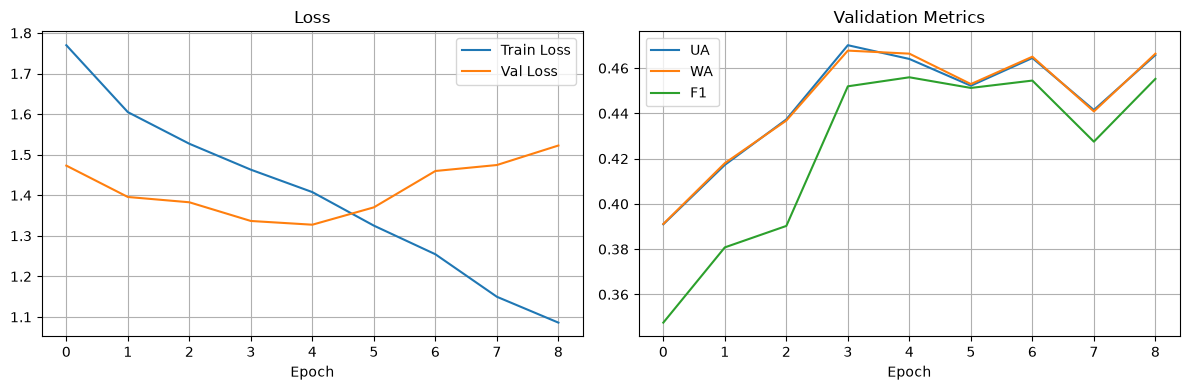

In [12]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid()

axes[1].plot(history["val_ua"], label="UA")
axes[1].plot(history["val_wa"], label="WA")
axes[1].plot(history["val_f1"], label="F1")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.savefig(f"{CHECKPOINT_DIR}/training_curves.png", dpi=100, bbox_inches='tight')
plt.show()

In [13]:
# Test
model.load_state_dict(torch.load(f"{CHECKPOINT_DIR}/best_model.pth", map_location=device))
test_result = evaluate(model, test_loader, criterion, device)

print("\n" + "="*50)
print("FINAL TEST RESULT")
print("="*50)
print(f"WA: {test_result['wa']:.4f}")
print(f"UA: {test_result['ua']:.4f}")
print(f"F1: {test_result['f1']:.4f}")
print("="*50)

# Classification report
emotion_names = {v: k for k, v in EMOTION_MAP.items()}
target_names = [emotion_names[i] for i in range(NUM_CLASSES)]
print("\nClassification Report:")
print(classification_report(test_result['y_true'], test_result['y_pred'], target_names=target_names))


FINAL TEST RESULT
WA: 0.4533
UA: 0.4552
F1: 0.4389

Classification Report:
              precision    recall  f1-score   support

         ANG       0.61      0.63      0.62       255
         DIS       0.44      0.36      0.39       254
         FEA       0.35      0.31      0.33       254
         HAP       0.39      0.20      0.27       255
         NEU       0.47      0.53      0.50       217
         SAD       0.43      0.69      0.53       254

    accuracy                           0.45      1489
   macro avg       0.45      0.46      0.44      1489
weighted avg       0.45      0.45      0.44      1489

